### APPROXIMATE NEAREST NEIGHBORS

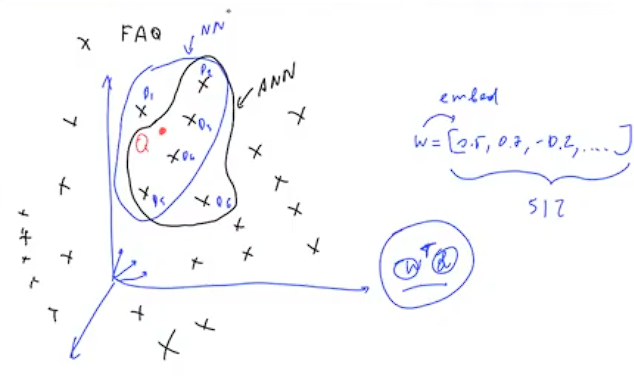

- NN (exact):    compare query against ALL documents -> top 5
- ANN (approx):  narrow down to a region -> compare within region -> top 5

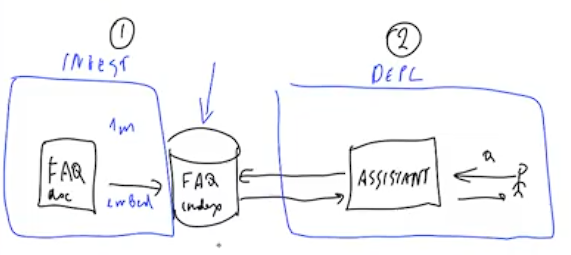

INGESTION -> DEPLOYMENT

In [2]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [3]:
from sqlitesearch import VectorSearchIndex

vs_index = VectorSearchIndex(
    keyword_fields=["course"],
    mode="ivf",
    db_path="faq_vectors2.db"
)

In [4]:
query_vector = model.encode("How do I run Kafka?")
results = vs_index.search(query_vector, num_results=5)
results

[{'course': 'data-engineering-zoomcamp',
  'section': 'Module 7: Streaming',
  'question': 'Java Kafka: How to run producer/consumer/kstreams/etc in terminal',
  'answer': 'In the project directory, run:\n\n```bash\njava -cp build/libs/<jar_name>-1.0-SNAPSHOT.jar:out src/main/java/org/example/JsonProducer.java\n```',
  'doc_id': '5ca6890c1a'},
 {'course': 'data-engineering-zoomcamp',
  'section': 'Module 7: Streaming',
  'question': 'Java Kafka: When running the producer/consumer/etc java scripts, no results retrieved or no message sent',
  'answer': 'For example, when running `JsonConsumer.java`, you might see:\n\n```\nConsuming form kafka started\n\nRESULTS:::0\n\nRESULTS:::0\n\nRESULTS:::0\n```\n\nOr when running `JsonProducer.java`, you might encounter:\n\n```\nException in thread "main" java.util.concurrent.ExecutionException: org.apache.kafka.common.errors.SaslAuthenticationException: Authentication failed\n```\n\n**Solution:**\n\n1. Ensure the `StreamsConfig.BOOTSTRAP_SERVERS_CO

In [5]:
results = vs_index.search(
    query_vector,
    filter_dict={"course": "llm-zoomcamp"},
    num_results=5
)
results

[{'course': 'llm-zoomcamp',
  'section': 'Module 1: RAG',
  'question': 'Ollama: How to install Ollama?',
  'answer': 'First, install Ollama by visiting [https://ollama.com/download](https://ollama.com/download) and choosing your operating system:\n\n- **macOS**: Download the `.pkg` and install it.\n- **Windows**: Download the `.msi` and install it.\n- **Linux**: Run the following command in the terminal:\n\n  ```bash\n  curl -fsSL https://ollama.com/install.sh | sh\n  ```\n\nOnce installed, open a terminal and type:\n\n```bash\nollama run llama3\n```\n\nThis command will:\n\n- Download the LLaMA 3 model (~4GB).\n- Start the model locally.\n- Open a chat-like interface where you can type questions.\n\nTo test the Ollama local server, run the following command:\n\n```bash\ncurl http://localhost:11434\n```\n\nYou should receive a response similar to:\n\n```json\n{"models": [...]}  \n```\n\nThen, install the Python client with:\n\n```bash\npip install ollama\n```\n\nHere is a minimal Pyth

In [6]:
from rag_helper import RAGBase
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()
openai_client = OpenAI()

class RAGVector(RAGBase):

    def __init__(self, embedder, **kwargs):
        super().__init__(**kwargs)
        self.embedder = embedder

    def search(self, query, num_results=5):
        query_vector = self.embedder.encode(query)
        filter_dict = {"course": self.course}

        return self.index.search(
            query_vector,
            num_results=num_results,
            filter_dict=filter_dict
        )

vector_assistant = RAGVector(
    embedder=model,
    index=vs_index,
    llm_client=openai_client,
)

In [7]:
vector_assistant.rag("the program has already begun, can I still sign up?")


'Yes, you can still join. If you want a certificate, make sure you submit your project while submissions are still open.'

In [8]:
vector_assistant.rag("the program is active now, can I inscribe now?")

'Yes — you can start learning and submitting homework now while the form is open. If you want a certificate, make sure you submit your project while submissions are still being accepted.'

In [9]:
vs_index.close()